In [1]:
import numpy as np
import os
import glob
from scipy import signal
import matplotlib.pyplot as plt
import matplotlib as mpl
import bat_functions as bf
from moviepy.editor import VideoFileClip

In [2]:
fps = 25

In [3]:
plots_save_folder = 'H:\\kasanka-bats\\plots\\wing-beat-analysis'
os.makedirs(plots_save_folder, exist_ok=True)

In [4]:
process_raw_tracks = True

if process_raw_tracks:
    folders = glob.glob(
        'H:\\kasanka-bats\\*2019'
    )
    day_folders = sorted(folders)
    min_thresh = 100
    print(day_folders)
    observations = {}
    for day_folder in day_folders[:]:
        print(day_folder)

        date = os.path.basename(day_folder)
        track_files = sorted(
            glob.glob(os.path.join(day_folder, '*\\raw_tracks.npy'))
        )
        for t_ind, track_file in enumerate(track_files):
            new_file = os.path.join(os.path.dirname(track_file), 
                                f'long_tracks_min_{min_thresh}.npy')
            if os.path.exists(new_file):
                continue
            tracks_raw = np.load(track_file, allow_pickle=True)
            tracks = bf.threshold_short_tracks(tracks_raw, 
                                               min_length_threshold=min_thresh)

            np.save(new_file, tracks)

['H:\\kasanka-bats\\12-Dec-2019', 'H:\\kasanka-bats\\24-Nov-2019', 'H:\\kasanka-bats\\27-Nov-2019', 'H:\\kasanka-bats\\28-Nov-2019', 'H:\\kasanka-bats\\3-Dec-2019', 'H:\\kasanka-bats\\6-Dec-2019']
H:\kasanka-bats\12-Dec-2019
H:\kasanka-bats\24-Nov-2019
H:\kasanka-bats\27-Nov-2019
H:\kasanka-bats\28-Nov-2019
H:\kasanka-bats\3-Dec-2019
H:\kasanka-bats\6-Dec-2019


In [5]:
def save_fig(save_folder, plot_title, fig=None):
    plot_name = plot_title.replace(' ', '-')
    file = os.path.join(save_folder, plot_name+'.png')
    if fig:
        fig.savefig(file, bbox_inches='tight', dpi=600)
        return
    
    plt.savefig(file, bbox_inches='tight', dpi=600)

In [6]:
def get_track_wingbeat_freqs(track, fps=25, min_freq=.75):
    """ Calculate peak wing freqs and assosiated power.
    
    track: track dict
    fps: frames per second track temporal resolution
    min_freq: minimum frequency for calculating peak_freq.
        Messily segmented tracks often have have high power
        close to 0 Hz because actual signal is not clear.
    """
    
    assert 'max_edge' in track.keys(), "Track must have max_edge already computed"
    
    if len(track['max_edge']) < 255:
        nperseg = len(track['max_edge'])
    else:
        nperseg = 255

    f, p = signal.welch(track['max_edge'], fps, nperseg=nperseg)
    peaks = signal.find_peaks(p, threshold=0, height=1)[0]

    track['freqs'] = f[peaks]
    track['freqs_power'] = p[peaks]

    peak_freq, freq_power  = bf.get_peak_freq(track['freqs'],
                                       track['freqs_power'],
                                       min_freq
                                      )
    track['peak_freq'] = peak_freq
    track['peak_freq_power'] = freq_power
    
def add_wingbeat_info_to_tracks(tracks, fps=25, min_freq=.75, 
                                remove_contours=False):
    """ Add main wingbeat freq info for all tracks in tracks after calculating
    all nessissary extra info. Can remove contours after getting bounding rects 
    to save memory.
    
    tracks: list of track dicts
    fps: frames per second - temporal resolution of tracks
    min_freq: minimum frequency for calculating peak_freq.
        Messily segmented tracks often have have high power
        close to 0 Hz because actual signal is not clear.
    remove_contours: if True remove raw contour info from track dicts.
        Useful if need to save memory
    """
    for track in tracks:
        if 'rects' not in track.keys():
            track['rects'] = bf.get_rects(track)
        if remove_contours:
            try:
                del track['contour']
            except KeyError:
                pass
                
        if 'max_edge' not in track.keys():
            track['max_edge'] = np.nanmax(track['rects'], 1)
        if 'mean_wing' not in track.keys():
            track['mean_wing'] = bf.get_wingspan(track)
        
        get_track_wingbeat_freqs(track, fps=fps, min_freq=min_freq)

In [7]:
print(day_folders[:])

['H:\\kasanka-bats\\12-Dec-2019', 'H:\\kasanka-bats\\24-Nov-2019', 'H:\\kasanka-bats\\27-Nov-2019', 'H:\\kasanka-bats\\28-Nov-2019', 'H:\\kasanka-bats\\3-Dec-2019', 'H:\\kasanka-bats\\6-Dec-2019']


In [8]:
process_long_tracks = True
remove_contours = True
overwrite = False

if process_long_tracks:

    folders = glob.glob(
        'H:\\kasanka-bats\\*2019'
    )
    camera_folders = glob.glob('F:\\KasankaCameras\\*2019')

    save_files = True
    day_folders = sorted(folders)
    min_thresh = 100

    all_tracks = {}
    for day_folder in day_folders[:]:
        print(day_folder)
        date = os.path.basename(day_folder)
        track_files = sorted(
            glob.glob(
                os.path.join(day_folder, f'*\\long_tracks_min_{min_thresh}.npy'))
        )
        # print(track_files)
        all_tracks[date] = {}
        for t_ind, track_file in enumerate(track_files):
            camera = track_file.split('\\')[-2]
            print(camera)
            
            # get fps
            files = glob.glob(os.path.join('F:\\KasankaCameras\\', date, camera, '*.MP4'))
            print(files)
            
            video_clip = VideoFileClip(files[0])
            fps = video_clip.fps
            print(fps)
            
            tracks = np.load(track_file, allow_pickle=True)
            add_wingbeat_info_to_tracks(tracks, 
                                        fps=fps, min_freq=.75, 
                                        remove_contours=remove_contours)
            if save_files:
                new_file = os.path.join(os.path.dirname(track_file), 
                                f'long_tracks_min_{min_thresh}_wingbeat.npy')
                if not os.path.exists(new_file) or overwrite:
                    np.save(new_file, tracks)
                    
            #break
        #break

H:\kasanka-bats\12-Dec-2019
BBC
['F:\\KasankaCameras\\12-Dec-2019\\BBC\\GH069854.MP4', 'F:\\KasankaCameras\\12-Dec-2019\\BBC\\GH079854.MP4', 'F:\\KasankaCameras\\12-Dec-2019\\BBC\\GH089854.MP4']
29.97002997002997
Chinangali
['F:\\KasankaCameras\\12-Dec-2019\\Chinangali\\GH040015.MP4', 'F:\\KasankaCameras\\12-Dec-2019\\Chinangali\\GH050015.MP4', 'F:\\KasankaCameras\\12-Dec-2019\\Chinangali\\GH060015.MP4']
29.97002997002997
Fibwe Parking
['F:\\KasankaCameras\\12-Dec-2019\\Fibwe Parking\\GH040017.MP4', 'F:\\KasankaCameras\\12-Dec-2019\\Fibwe Parking\\GH050017.MP4', 'F:\\KasankaCameras\\12-Dec-2019\\Fibwe Parking\\GH060017.MP4', 'F:\\KasankaCameras\\12-Dec-2019\\Fibwe Parking\\GH070017.MP4']
29.97002997002997
Fibwe Public
['F:\\KasankaCameras\\12-Dec-2019\\Fibwe Public\\GP029072.MP4', 'F:\\KasankaCameras\\12-Dec-2019\\Fibwe Public\\GP039072.MP4', 'F:\\KasankaCameras\\12-Dec-2019\\Fibwe Public\\GP049072.MP4']
25.0
Musola Parking
['F:\\KasankaCameras\\12-Dec-2019\\Musola Parking\\GP039960.MP

Musola Path
['F:\\KasankaCameras\\28-Nov-2019\\Musola Path\\GP029829.MP4', 'F:\\KasankaCameras\\28-Nov-2019\\Musola Path\\GP039829.MP4', 'F:\\KasankaCameras\\28-Nov-2019\\Musola Path\\GP049829.MP4']
29.97002997002997
Musola Tower
['F:\\KasankaCameras\\28-Nov-2019\\Musola Tower\\GP019314.MP4', 'F:\\KasankaCameras\\28-Nov-2019\\Musola Tower\\GP029314.MP4', 'F:\\KasankaCameras\\28-Nov-2019\\Musola Tower\\GP039314.MP4']
29.97002997002997
Not Chinangali
['F:\\KasankaCameras\\28-Nov-2019\\Not Chinangali\\GH032512.MP4', 'F:\\KasankaCameras\\28-Nov-2019\\Not Chinangali\\GH042512.MP4', 'F:\\KasankaCameras\\28-Nov-2019\\Not Chinangali\\GH052512.MP4', 'F:\\KasankaCameras\\28-Nov-2019\\Not Chinangali\\GH062512.MP4']
29.97002997002997
Puku
['F:\\KasankaCameras\\28-Nov-2019\\Puku\\GH020012.MP4', 'F:\\KasankaCameras\\28-Nov-2019\\Puku\\GH030012.MP4', 'F:\\KasankaCameras\\28-Nov-2019\\Puku\\GH040012.MP4', 'F:\\KasankaCameras\\28-Nov-2019\\Puku\\GH050012.MP4']
29.97002997002997
Sunset
['F:\\KasankaCame

In [9]:
tracks[0].keys()
plots_save_folder

'H:\\kasanka-bats\\plots\\wing-beat-analysis'

In [10]:
peak_freqs = [t['peak_freq'] for t in tracks if ((t['peak_freq'] >= 3) & (t['peak_freq'] < 4))]

(556,)
3.0392156862745114
3.137254901960786
3.2352941176470607
3.3333333333333353
3.43137254901961
3.5294117647058845
3.627450980392159
3.7254901960784337
3.8235294117647083
3.921568627450983


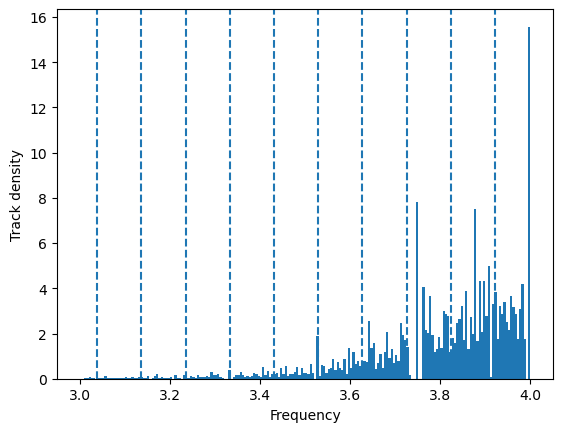

In [11]:
# plt.figure(figsize=(10,10))
peak_freqs = np.around(np.array(peak_freqs), 5)
unique_freqs = np.unique(peak_freqs)
print(unique_freqs.shape)
hist_info = plt.hist(peak_freqs, bins=200, density=True, range=(3,4))
# plt.figure()
# _ = plt.hist(all_freqs, bins=200, density=True, alpha=.7, range=(3, 4))

length = 255
freq_resolution = 25 / length
samples = np.ones(length) * freq_resolution
measured_freqs = np.cumsum(samples)
length_freqs = measured_freqs[(measured_freqs>=3.0)&(measured_freqs<4)]
for f in length_freqs:
    print(f)
    plt.axvline(f, ls='--')
    
plt.xlabel('Frequency')
plt.ylabel('Track density')

title = 'sampling derived frequency peak origins'

save_fig(plots_save_folder, title)

In [12]:
counts = hist_info[0]
bins = hist_info[1]

In [13]:
bin_ind =np.argmax(counts) 
min_bin_val, max_bin_val = bins[bin_ind:bin_ind+2]

In [14]:
focal_tracks = []
for t in tracks:
    if (t['peak_freq'] >= min_bin_val) and (t['peak_freq'] < max_bin_val):
        if len(t['max_edge']) > 0:
            focal_tracks.append(t)

print(len(focal_tracks))

1430


In [15]:
print(t['peak_freq'])

nan


In [16]:
25 / 256, 25/100

(0.09765625, 0.25)

In [17]:
# focal_peak = [t['first_frame'] for t in focal_tracks]
# focal_peak
# plt.scatter(focal_peak, np.arange(len(focal_peak)))

In [18]:
possible_frequencies = []
for t_num, t in enumerate(focal_tracks[::]):
    if len(t['max_edge']) < 255:
        nperseg = len(t['max_edge'])
    else:
        nperseg = 255
    
    f, p = signal.welch(t['max_edge'], fps, nperseg=nperseg)
    possible_frequencies.extend(f)
#     plt.figure()
#     plt.stem(f, p, use_line_collection=True)
#     plt.title(f"{len(f)}  {len(t['max_edge'])}")
#     peaks = signal.find_peaks(p, threshold=0, height=1)[0]
#     plt.figure()
#     plt.stem(t['freqs'], abs(t['freqs_power']), use_line_collection=True)
#     plt.title(t_num)
#     plt.figure()
#     plt.plot(t['max_edge'])
#     plt.title(t_num)


In [19]:
unique = np.unique(possible_frequencies)
threes = unique[(unique>=3)&(unique<4)]
threes.shape

(50,)

In [20]:
threes

array([3.05576776, 3.06360306, 3.07384923, 3.08782127, 3.10800311,
       3.12187812, 3.13971743, 3.16350316, 3.17329729, 3.1968032 ,
       3.22754169, 3.24675325, 3.26945781, 3.28243185, 3.29082682,
       3.33000333, 3.33000333, 3.37162837, 3.38123415, 3.3966034 ,
       3.40835635, 3.42514628, 3.45109436, 3.46320346, 3.4965035 ,
       3.52588588, 3.53492661, 3.55200355, 3.56786071, 3.5964036 ,
       3.62137862, 3.63273091, 3.64341541, 3.66300366, 3.68861907,
       3.71057514, 3.72960373, 3.74625375, 3.76094494, 3.77400377,
       3.7962038 , 3.81436745, 3.82950383, 3.84231153, 3.85328957,
       3.86280386, 3.87112887, 3.87847447, 3.996004  , 3.996004  ])

In [21]:
lengths = np.arange(100, 256)

In [22]:
freq_resolution = 25 / lengths

all_freqs = []

for length in lengths[::]:
    freq_resolution = 25 / length
    samples = np.ones(length) * freq_resolution
    measured_freqs = np.cumsum(samples)
    all_freqs.extend(measured_freqs[(measured_freqs < 4) & (measured_freqs >=3)])

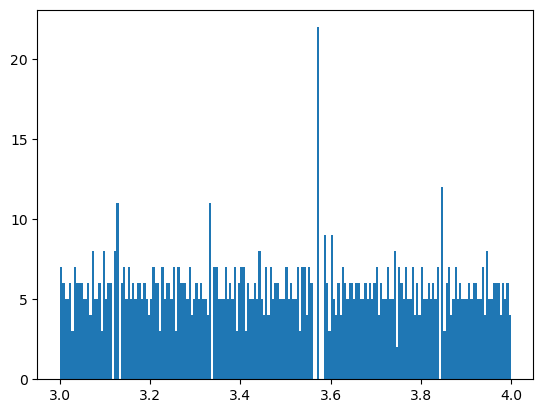

In [23]:

_ = plt.hist(all_freqs, bins=200)

(793,)


(array([ 8.,  7.,  8.,  9.,  7., 10.,  7.,  9.,  9.,  8., 11.,  6.,  1.,
         6., 11.,  9.,  9.,  9.,  8.,  7.,  8.,  9.,  6.,  9.,  8.,  8.,
         7.,  8.,  9.,  9.,  7.,  9.,  9.,  1., 12.,  8.,  9.,  7., 10.,
         7.,  7.,  8.,  8.,  7.,  8., 10.,  9.,  6.,  7.,  9.,  7., 10.,
         9.,  8.,  9., 13.,  0.,  1.,  9.,  9., 10.,  8.,  8.,  8.,  9.,
         8.,  8.,  7.,  9., 10.,  6.,  8.,  9.,  8.,  7.,  8.,  9.,  8.,
         7.,  8.,  8.,  8.,  9., 11.,  1.,  9.,  8.,  9.,  8.,  7.,  8.,
         9.,  6., 10.,  5.,  9.,  8.,  7.,  9.,  8.]),
 array([3.  , 3.01, 3.02, 3.03, 3.04, 3.05, 3.06, 3.07, 3.08, 3.09, 3.1 ,
        3.11, 3.12, 3.13, 3.14, 3.15, 3.16, 3.17, 3.18, 3.19, 3.2 , 3.21,
        3.22, 3.23, 3.24, 3.25, 3.26, 3.27, 3.28, 3.29, 3.3 , 3.31, 3.32,
        3.33, 3.34, 3.35, 3.36, 3.37, 3.38, 3.39, 3.4 , 3.41, 3.42, 3.43,
        3.44, 3.45, 3.46, 3.47, 3.48, 3.49, 3.5 , 3.51, 3.52, 3.53, 3.54,
        3.55, 3.56, 3.57, 3.58, 3.59, 3.6 , 3.61, 3.62, 3.63, 3.

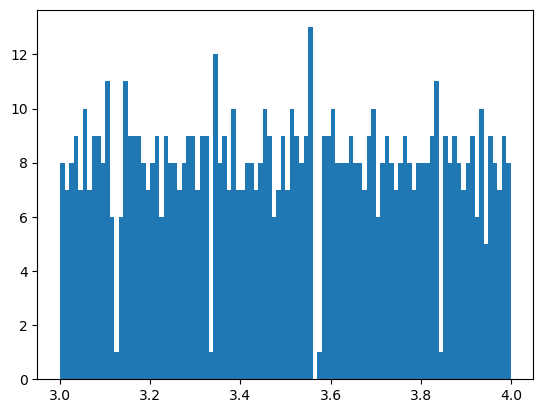

In [24]:

unique = np.unique(np.around(np.array(all_freqs), 5))
print(unique.shape)
plt.hist(unique, bins=100)

In [25]:
freqs  = np.array(all_freqs)

In [26]:
np.unique(freqs).shape

(1010,)

In [27]:
np.unique(np.ones(10)*1.1)

array([1.1])